In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as cticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import matplotlib.patches as mpatches
from datetime import datetime, timedelta, timezone
import configparser



## directory where to save or look for data
current_dir = "/home/paaa/python_scripts"
out_dir     = "/perm/paaa/images/CATRINE"
data_dir    = "/scratch/paaa/glob_co2_compare"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

inidate="20220515"
enddate="20220520"
initime="0"
step="1/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24" # in UTC

day_hours   = [8, 19] # in local time  (currently unused — define intent to use)
night_hours = [7, 20] # in local time  (currently unused — define

plot_date  = inidate  # initialization date for the snapshot map (YYYYMMDD)
plot_step  = 5        # forecast step (hours) for the snapshot map
plot_level = 137      # model level to plot (must be one of: 120, 125, 130, 137)

runids = [
    ("iyw7",            "Control",          "#244865"),  # blue
    # ("j1m9",           "05 diff, stable",    "#e41a1c"),  # red
    ('j7fk',             'S_tail' ,          '#59981A'),
    ('j7y2'            , 'dryMF'             ,"#7C1471"),
]

experiments_srf = {}
experiments_ml = {}

cabauw = {
    "lat": 51.971,
    "lon": 4.927,
}
loobos = {
    "lat": 52.1665,
    "lon": 5.7435,
}


In [2]:
def concentration_to_ppm(gas,concentration):
    """
    Convert concentration of co2 to ppm 
    Input:
         gas = name of the gas 
         concentration    = concentration in g/g
    """
    if gas == 'co2':
        mmgas=44.0095 # g/mol
    elif gas =='ra':
        mmgas=222 # g/mol
    elif gas =='ch4':
        mmgas=16.04 # g/mol
    else:
        raise ValueError("Gas wrongly specified or not known.")
    
    mmair=28.9644 #g/mol # assumption of dry air
    ppm = 10**6 *concentration * mmair/mmgas 
    return ppm

def wrap_lon(lon):
    lon = float(lon)
    if lon > 180:
        lon -= 360
    return lon

In [3]:
# Global model levels — co2 and ch4 at 120/125/130/137
for (runid, _, _) in runids:
    print(f"###### Processing {runid} ######")
    target_file = f'{data_dir}/{runid}_ml_globe_{inidate}to{enddate}.grib'
    if not os.path.exists(target_file):
        print(f"grib not found for {runid} ML. Retrieving from MARS...")
        req_file = f"{current_dir}/mars_request_{runid}_ml_globe"
        req = {
            "class":    "rd",
            "type":     "fc",
            "date":     f"{inidate}/to/{enddate}",
            "expver":   runid,
            "param":    "co2",
            "levelist": "120/125/130/137",
            "step":     step,
            "stream":   "oper",
            "time":     initime,
            "grid":     "0.2/0.2",
            "area":     "global",
            "levtype":  "ml",
            "target":   f'"{target_file}"',
        }
        kv = ['{}={}'.format(k, v) for k, v in req.items()]
        kv = 'retrieve,{}'.format(','.join(kv))
        print(kv)
        with open(req_file, "w") as f:
            f.write(kv)
        os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
    else:
        print(f"grib already exists for {runid} model levels.")


###### Processing iyw7 ######
grib already exists for iyw7 model levels.
###### Processing j7fk ######
grib already exists for j7fk model levels.
###### Processing j7y2 ######
grib already exists for j7y2 model levels.


In [4]:
# Surface level
for (runid, _, _) in runids:
    print(f"###### Processing {runid} ######")
    target_file = f'{data_dir}/{runid}_sfc_europe_{inidate}to{enddate}.grib'
    if not os.path.exists(target_file):
        print(f"grib not found for {runid} SFC. Retrieving from MARS...")
        req_file = f"{current_dir}/mars_request_{runid}_sfc"
        req = {
            "class":   "rd",
            "type":    "fc",
            "date":    f"{inidate}/to/{enddate}",
            "expver":  runid,
            "param":   "2t/blh/64.210/65.210/80.228/210061/210062",
            "step":    step,
            "stream":  "oper",
            "time":    initime,
            "grid":    "0.2/0.2",
            "area":    "70/-20/30/50",  # N/W/S/E — Europe
            "levtype": "sfc",
            "target":  f'"{target_file}"',
        }
        kv = ['{}={}'.format(k, v) for k, v in req.items()]
        kv = 'retrieve,{}'.format(','.join(kv))
        print(kv)
        with open(req_file, "w") as f:
            f.write(kv)
        os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
    else:
        print(f"grib already exists for {runid} surface.")


###### Processing iyw7 ######
grib already exists for iyw7 surface.
###### Processing j7fk ######
grib already exists for j7fk surface.
###### Processing j7y2 ######
grib already exists for j7y2 surface.


In [5]:
experiments_srf["2t"]      = {}
experiments_srf["blh"]     = {}
experiments_srf["co2"]     = {}
experiments_srf["co2_ppm"] = {}

for (runid, _, _) in runids:
    target_file = f'{data_dir}/{runid}_sfc_europe_{inidate}to{enddate}.grib'

    ds_t = xr.open_dataset(target_file, engine='cfgrib',
                           filter_by_keys={'shortName': '2t'})
    experiments_srf["2t"][runid] = ds_t['t2m']

    ds_blh = xr.open_dataset(target_file, engine='cfgrib',
                              filter_by_keys={'shortName': 'blh'})
    experiments_srf["blh"][runid] = ds_blh['blh']

    ds_co2 = xr.open_dataset(target_file, engine='cfgrib',
                              filter_by_keys={'shortName': 'co2', 'typeOfLevel': 'surface'})
    experiments_srf["co2"][runid] = ds_co2['co2']
    experiments_srf["co2_ppm"][runid] = xr.DataArray(
        concentration_to_ppm('co2', ds_co2['co2'].values),
        coords=ds_co2['co2'].coords,
        dims=ds_co2['co2'].dims,
    )


In [6]:
# Wind components (u, v) on model level plot_level
for (runid, _, _) in runids:
    print(f"###### Processing {runid} winds ######")
    target_file = f'{data_dir}/{runid}_wind{plot_level}_europe_{inidate}to{enddate}.grib'
    if not os.path.exists(target_file):
        print(f"grib not found for {runid} wind ml. Retrieving from MARS...")
        req_file = f"{current_dir}/mars_request_{runid}_wind{plot_level}"
        req = {
            "class":    "rd",
            "type":     "fc",
            "date":     f"{inidate}/to/{enddate}",
            "expver":   runid,
            "param":    "u/v",
            "levelist": str(plot_level),
            "step":     step,
            "stream":   "oper",
            "time":     initime,
            "grid":     "0.2/0.2",
            "area":     "70/-20/30/50",  # N/W/S/E — Europe
            "levtype":  "ml",
            "target":   f'"{target_file}"',
        }
        kv = ['{}={}'.format(k, v) for k, v in req.items()]
        kv = 'retrieve,{}'.format(','.join(kv))
        print(kv)
        with open(req_file, "w") as f:
            f.write(kv)
        os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
    else:
        print(f"grib already exists for {runid} wind ml.")


###### Processing iyw7 winds ######
grib already exists for iyw7 wind ml.
###### Processing j7fk winds ######
grib already exists for j7fk wind ml.
###### Processing j7y2 winds ######
grib already exists for j7y2 wind ml.


In [7]:
experiments_ml = {f"co2_{l}": {} for l in ["137", "130", "125", "120"]}
experiments_ml[f"co2_{plot_level}_ppm"] = {}
experiments_globe = {}

def to_180(ds):
    """Convert longitude coordinate from 0–360 to –180/180 and sort."""
    return (ds
            .assign_coords(longitude=((ds.longitude + 180) % 360) - 180)
            .sortby('longitude'))

for runid, _, _ in runids:
    target_file = f'{data_dir}/{runid}_ml_globe_{inidate}to{enddate}.grib'
    ds = xr.open_dataset(target_file, engine='cfgrib',
                         filter_by_keys={'shortName': 'co2', 'typeOfLevel': 'hybrid'})

    # --- Global (0–360 lons) — for difference map ---
    co2_kg_globe = ds['co2'].sel(hybrid=plot_level)
    experiments_globe[runid] = xr.DataArray(
        concentration_to_ppm('co2', co2_kg_globe.values),
        coords=co2_kg_globe.coords,
        dims=co2_kg_globe.dims,
    )

    # --- Europe subset (–180/180 lons) — for regional plots ---
    ds_eu = to_180(ds).sel(latitude=slice(70, 30), longitude=slice(-20, 50))
    for level in ["137", "130", "125", "120"]:
        experiments_ml[f"co2_{level}"][runid] = ds_eu['co2'].sel(hybrid=int(level))

    co2_kg = experiments_ml[f"co2_{plot_level}"][runid]
    experiments_ml[f"co2_{plot_level}_ppm"][runid] = xr.DataArray(
        concentration_to_ppm('co2', co2_kg.values),
        coords=co2_kg.coords,
        dims=co2_kg.dims,
    )


In [8]:
# Extract u and v winds on model level plot_level, aligned to the CO2 lat/lon grid
experiments_ml[f"u_{plot_level}"] = {}
experiments_ml[f"v_{plot_level}"] = {}

# Reference grid from CO2 data (Europe, –180/180 lons)
_runid0 = runids[0][0]
_eu_lats = experiments_ml[f"co2_{plot_level}"][_runid0].latitude.values
_eu_lons = experiments_ml[f"co2_{plot_level}"][_runid0].longitude.values

for runid, _, _ in runids:
    target_file = f'{data_dir}/{runid}_wind{plot_level}_europe_{inidate}to{enddate}.grib'
    ds_u = xr.open_dataset(target_file, engine='cfgrib',
                            filter_by_keys={'shortName': 'u', 'typeOfLevel': 'hybrid', 'level': plot_level})
    ds_v = xr.open_dataset(target_file, engine='cfgrib',
                            filter_by_keys={'shortName': 'v', 'typeOfLevel': 'hybrid', 'level': plot_level})
    # Convert lons to –180/180 and interpolate onto the CO2 grid so shapes match
    experiments_ml[f"u_{plot_level}"][runid] = to_180(ds_u)['u'].interp(latitude=_eu_lats, longitude=_eu_lons)
    experiments_ml[f"v_{plot_level}"][runid] = to_180(ds_v)['v'].interp(latitude=_eu_lats, longitude=_eu_lons)


In [31]:
def select_and_mean(da, steps=None):
    """Optionally filter by forecast step, then average over non-spatial dims."""
    spatial_dims = {'latitude', 'longitude', 'hybrid'}
    if steps is not None and 'step' in da.dims:
        step_td = [np.timedelta64(s, 'h') for s in steps]
        da = da.sel(step=step_td)
    time_dims = [d for d in da.dims if d not in spatial_dims]
    return da.mean(dim=time_dims) if time_dims else da

REGIONS = [
    ('Arctic',  60,  90, -180,  180),
    ('USA',     29,  60, -130,  -58),
    ('Europe',  35,  60,  -12.5, 25),
]


# Load ICOS stations from obs.cfg
def load_stations(cfg_file, dtypes=('tower-insitu', 'surface-insitu'), networks=()):
    cfg = configparser.RawConfigParser()
    cfg.read(cfg_file)
    stations = []
    for sec in cfg.sections():
        dtype   = cfg.get(sec, 'data type') if cfg.has_option(sec, 'data type') else ''
        network = cfg.get(sec, 'network')   if cfg.has_option(sec, 'network')   else ''
        if dtype in dtypes or network in networks:
            lat = float(cfg.get(sec, 'latitude'))  if cfg.has_option(sec, 'latitude')  else np.nan
            lon = float(cfg.get(sec, 'longitude')) if cfg.has_option(sec, 'longitude') else np.nan
            stations.append({'lat': lat, 'lon': lon})
    return stations

obs_cfg = f"/perm/paaa/ECSMD_COMPO/iyw7/obs.cfg"
icos_stations = load_stations(obs_cfg)
st_lons = np.array([s['lon'] for s in icos_stations if np.isfinite(s['lon'])])
st_lats = np.array([s['lat'] for s in icos_stations if np.isfinite(s['lat'])])

## PLOT

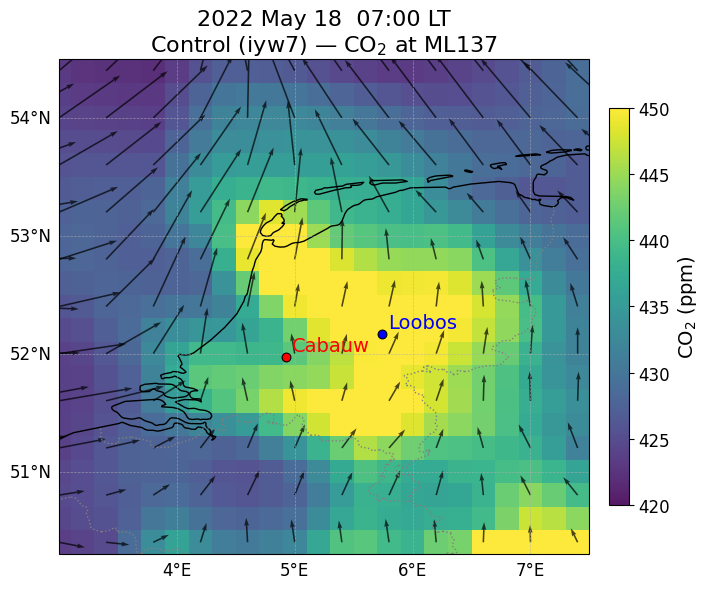

In [ ]:
########################
########  Maps  ########
########################
runid, name, color = runids[0]

# Compute valid time (UTC+2) from plot_date, initime and plot_step
utc_dt = datetime(int(plot_date[:4]), int(plot_date[4:6]), int(plot_date[6:8]),
                  int(initime), tzinfo=timezone.utc) + timedelta(hours=plot_step)
local_dt = utc_dt + timedelta(hours=2)
local_time_str = local_dt.strftime("%Y %b %d  %H:%M LT")

# CO2 in ppm at model level plot_level — select specific (init date, forecast step)
co2_ppm = experiments_ml[f"co2_{plot_level}_ppm"][runid]
plot_init_np = np.datetime64(
    f"{plot_date[:4]}-{plot_date[4:6]}-{plot_date[6:8]}T{int(initime):02d}:00")
sel_kw = {}
if 'time' in co2_ppm.dims:
    sel_kw['time'] = plot_init_np
if 'step' in co2_ppm.dims:
    sel_kw['step'] = np.timedelta64(plot_step, 'h')
co2_ppm_snap = co2_ppm.sel(**sel_kw).squeeze()
lats = co2_ppm_snap.latitude.values
lons = co2_ppm_snap.longitude.values
co2_data = co2_ppm_snap.values

# Winds at model level plot_level — same selection
ds_u = experiments_ml[f"u_{plot_level}"][runid]
ds_v = experiments_ml[f"v_{plot_level}"][runid]
u_data = ds_u.sel(**{k: v for k, v in sel_kw.items() if k in ds_u.dims}).squeeze().values
v_data = ds_v.sel(**{k: v for k, v in sel_kw.items() if k in ds_v.dims}).squeeze().values

# Define the projection
projection = ccrs.PlateCarree()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})

# Plot CO2 field
vmin = 420
vmax = 450
mesh = ax.pcolormesh(lons, lats, co2_data, cmap='viridis', alpha=0.9,
                     vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label("CO$_2$ (ppm)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Add coastlines and borders
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

# Set extent to focus on the Netherlands region
ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
# ax.set_extent([4.45, 5.92, 51.6, 52.5], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = cticker.MaxNLocator(5)
gl.ylocator = cticker.MaxNLocator(5)
gl.xlabel_style = {"size": 12, "color": "black"}
gl.ylabel_style = {"size": 12, "color": "black"}

# Wind arrows at model level plot_level (subsampled to avoid overcrowding)
skip = 2
ax.quiver(lons[::skip], lats[::skip],
          u_data[::skip, ::skip], v_data[::skip, ::skip],
          transform=ccrs.PlateCarree(), scale=50, color='k', alpha=0.7, width=0.003)

# Cabauw
ax.scatter(cabauw['lon'], cabauw['lat'], color='red', s=40, marker='o',
           transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
ax.text(cabauw['lon'] + 0.05, cabauw['lat'] + 0.05, 'Cabauw',
        color='red', fontsize=14, transform=ccrs.PlateCarree())

# Loobos
ax.scatter(loobos['lon'], loobos['lat'], color='blue', s=40, marker='o',
           transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
ax.text(loobos['lon'] + 0.05, loobos['lat'] + 0.05, 'Loobos',
        color='blue', fontsize=14, transform=ccrs.PlateCarree())

plt.title(f"{local_time_str}\n{name} ({runid}) — CO$_2$ at ML{plot_level}", fontsize=16)
plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f"{out_dir}/{runid}_co2_ml{plot_level}_europe_{plot_date}_{plot_step}h.png",
            dpi=150, bbox_inches='tight')
plt.show()


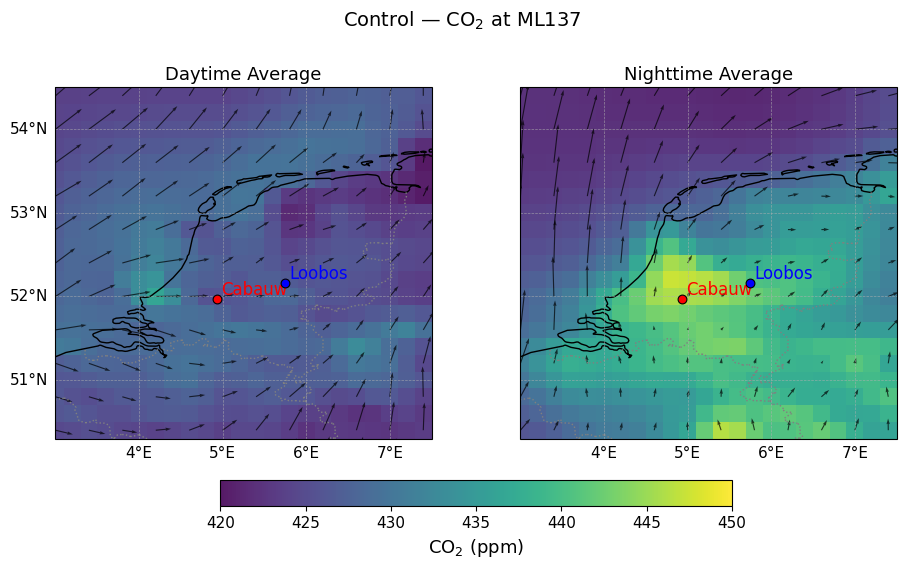

In [ ]:

########################
##  Day / Night Maps  ##
########################
UTC_OFFSET = 2  # hours ahead of UTC for the Netherlands

runid, name, color = runids[0]

def filtered_mean(da, h_min, h_max, night=False):
    """
    Average da over timesteps whose local hour satisfies the filter.
      night=False (day):  h_min <= local_hour <= h_max
      night=True:         local_hour < h_min  OR  local_hour >= h_max
    """
    spatial_dims = {'latitude', 'longitude', 'hybrid'}
    time_dims = [d for d in da.dims if d not in spatial_dims]
    if not time_dims:
        return da
    # Compute valid_time by broadcasting init time + forecast step
    if 'time' in da.dims and 'step' in da.dims:
        vt = da.time + da.step          # broadcasts to (time, step)
    elif 'valid_time' in da.coords:
        vt = da.valid_time
    else:
        return da.mean(dim=time_dims)
    local_hour = (vt + pd.Timedelta(hours=UTC_OFFSET)).dt.hour
    if night:
        mask = (local_hour < h_min) | (local_hour >= h_max)
    else:
        mask = (local_hour >= h_min) & (local_hour <= h_max)
    return da.where(mask).mean(dim=time_dims)

# Build time-range label (inidate+step[0] → enddate+step[-1])
steps = [int(s) for s in step.split("/")]
utc_start = datetime(int(inidate[:4]), int(inidate[4:6]), int(inidate[6:8]),
                     int(initime), tzinfo=timezone.utc) + timedelta(hours=steps[0])
utc_end   = datetime(int(enddate[:4]), int(enddate[4:6]), int(enddate[6:8]),
                     int(initime), tzinfo=timezone.utc) + timedelta(hours=steps[-1])
time_range_str = (f"{utc_start.strftime('%Y %b %d %H:%M')} – "
                  f"{utc_end.strftime('%Y %b %d %H:%M')} UTC")

# ---- Compute averages ----
co2_ppm_all = experiments_ml[f"co2_{plot_level}_ppm"][runid]
u_all       = experiments_ml[f"u_{plot_level}"][runid]
v_all       = experiments_ml[f"v_{plot_level}"][runid]

co2_day = filtered_mean(co2_ppm_all, day_hours[0],   day_hours[1],   night=False)
co2_ngt = filtered_mean(co2_ppm_all, night_hours[0], night_hours[1], night=True)
u_day   = filtered_mean(u_all,       day_hours[0],   day_hours[1],   night=False)
v_day   = filtered_mean(v_all,       day_hours[0],   day_hours[1],   night=False)
u_ngt   = filtered_mean(u_all,       night_hours[0], night_hours[1], night=True)
v_ngt   = filtered_mean(v_all,       night_hours[0], night_hours[1], night=True)

lats = co2_day.latitude.values
lons = co2_day.longitude.values
vmin, vmax = 420, 450

panels = [
    (co2_day.values, u_day.values, v_day.values,
     f"Daytime Average"),
    (co2_ngt.values, u_ngt.values, v_ngt.values,
     f"Nighttime Average"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})

mesh = None
for i, (ax, (co2, u, v, title)) in enumerate(zip(axes, panels)):
    mesh = ax.pcolormesh(lons, lats, co2, cmap='viridis', alpha=0.9,
                         vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels   = False
    gl.right_labels = False
    gl.left_labels  = (i == 0)
    gl.xlocator     = cticker.MaxNLocator(5)
    gl.ylocator     = cticker.MaxNLocator(5)
    gl.xlabel_style = {"size": 11, "color": "black"}
    gl.ylabel_style = {"size": 11, "color": "black"}
    skip = 2
    ax.quiver(lons[::skip], lats[::skip], u[::skip, ::skip], v[::skip, ::skip],
              transform=ccrs.PlateCarree(), scale=30, color='k', alpha=0.7, width=0.003)
    ax.scatter(cabauw['lon'], cabauw['lat'], color='red', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(cabauw['lon'] + 0.05, cabauw['lat'] + 0.05, 'Cabauw',
            color='red', fontsize=12, transform=ccrs.PlateCarree())
    ax.scatter(loobos['lon'], loobos['lat'], color='blue', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(loobos['lon'] + 0.05, loobos['lat'] + 0.05, 'Loobos',
            color='blue', fontsize=12, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=13)

# Common colorbar — horizontal below the panels
cbar = fig.colorbar(mesh, ax=axes.tolist(), orientation='horizontal', shrink=0.6, pad=0.09)
cbar.set_label("CO$_2$ (ppm)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(f"{name} — CO$_2$ at ML{plot_level}", fontsize=14, y=1.01)

os.makedirs(out_dir, exist_ok=True)
plt.savefig(f"{out_dir}/{runid}_co2_ml{plot_level}_europe_{inidate}to{enddate}_daynight.png",
            dpi=150, bbox_inches='tight')
plt.show()


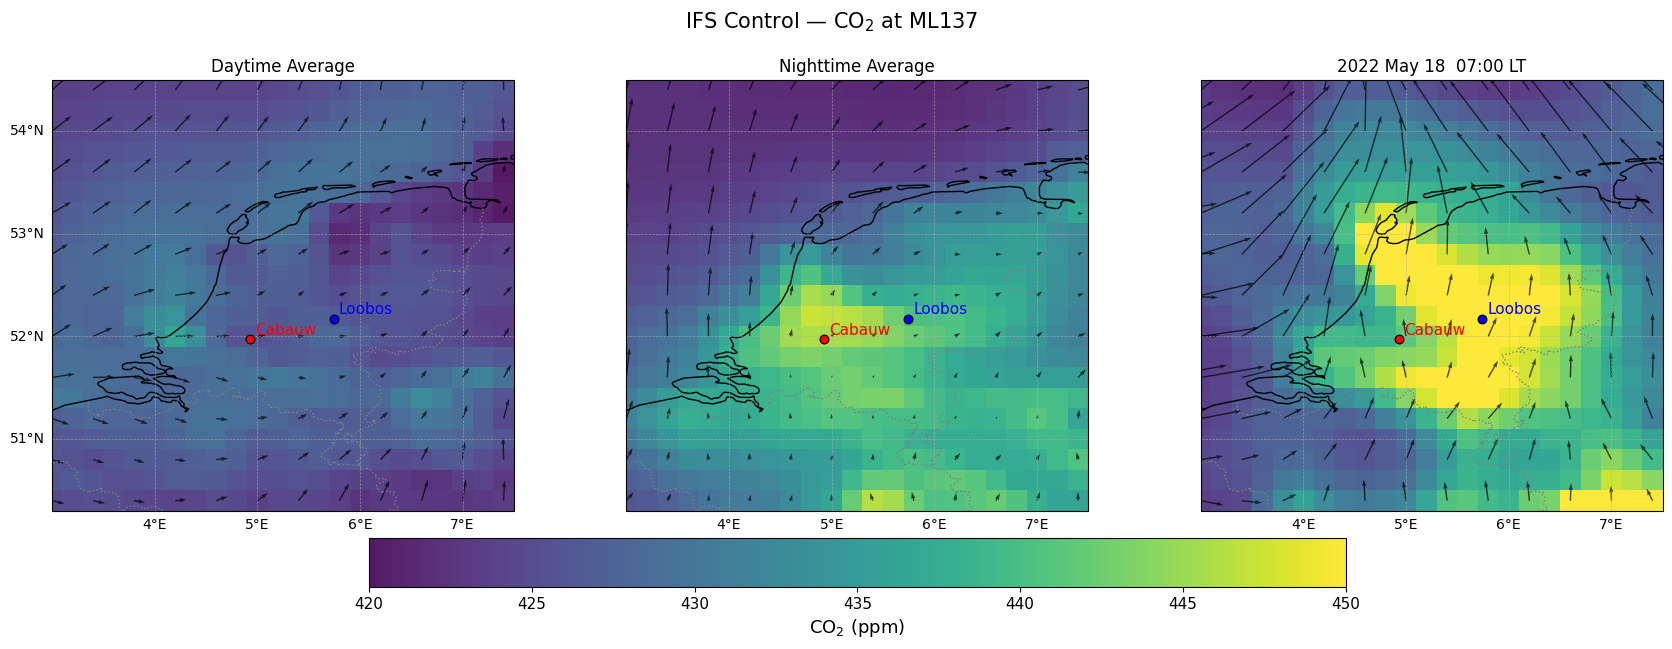

In [34]:

# Side-by-side: Daytime | Nighttime | Snapshot
vmin, vmax = 420, 450

panels = [
    (co2_day.values, u_day.values, v_day.values,
     f"Daytime Average"),
    (co2_ngt.values, u_ngt.values, v_ngt.values,
     f"Nighttime Average"),
    (co2_data,       u_data,       v_data,
     local_time_str),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

mesh = None
for i, (ax, (co2, u, v, title)) in enumerate(zip(axes, panels)):
    mesh = ax.pcolormesh(lons, lats, co2, cmap='viridis', alpha=0.9,
                         vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels   = False
    gl.right_labels = False
    gl.left_labels  = (i == 0)   # y-labels only on leftmost panel
    gl.xlocator     = cticker.MaxNLocator(5)
    gl.ylocator     = cticker.MaxNLocator(5)
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}
    skip = 2
    ax.quiver(lons[::skip], lats[::skip], u[::skip, ::skip], v[::skip, ::skip],
              transform=ccrs.PlateCarree(), scale=50, color='k', alpha=0.7, width=0.003)
    ax.scatter(cabauw['lon'], cabauw['lat'], color='red', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(cabauw['lon'] + 0.05, cabauw['lat'] + 0.05, 'Cabauw',
            color='red', fontsize=11, transform=ccrs.PlateCarree())
    ax.scatter(loobos['lon'], loobos['lat'], color='blue', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(loobos['lon'] + 0.05, loobos['lat'] + 0.05, 'Loobos',
            color='blue', fontsize=11, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)

# Common colorbar — horizontal below the panels
cbar = fig.colorbar(mesh, ax=axes.tolist(), orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label("CO$_2$ (ppm)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# Common suptitle (no repetition across panels)
fig.suptitle(f"IFS {name} — CO$_2$ at ML{plot_level}", fontsize=15, y=0.98)

plt.savefig(f"{out_dir}/{runid}_co2_ml{plot_level}_europe_{inidate}to{enddate}_panels.png",
            dpi=150, bbox_inches='tight')
plt.show()


In [18]:
runids

[('iyw7', 'Control', '#244865'),
 ('j7fk', 'S_tail', '#59981A'),
 ('j7y2', 'dryMF', '#7C1471')]

In [ ]:
diff.sel(latitude=slice(60, 40), longitude=slice(0, 25)).mean().values

diff.sel(longitude=slice(360-75, 360-50),latitude=slice(60, 40))

<xarray.DataArray (latitude: 901, longitude: 125)> Size: 450kB
array([[-1.8819173e-04, -1.8819173e-04, -1.8819173e-04, ...,
        -1.8819173e-04, -1.8819173e-04, -1.8819173e-04],
       [-3.3060709e-04, -3.4077963e-04, -3.2552084e-04, ...,
        -1.4241536e-04, -1.4750163e-04, -1.4241536e-04],
       [-5.2388507e-04, -5.2388507e-04, -5.3405762e-04, ...,
        -1.3732910e-04, -1.3732910e-04, -1.4750163e-04],
       ...,
       [ 0.0000000e+00, -5.0862632e-06,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)
Coordinates:
    hybrid     float64 8B 137.0
  * latitude   (latitude) float64 7kB 90.0 89.8 89.6 89.4 ... -89.6 -89.8 -90.0
  * longitude  (longitude) float64 1kB 285.2 285.4 285.6 ... 309.6 309.8 310.0

Regional mean: 0.13261979818344116


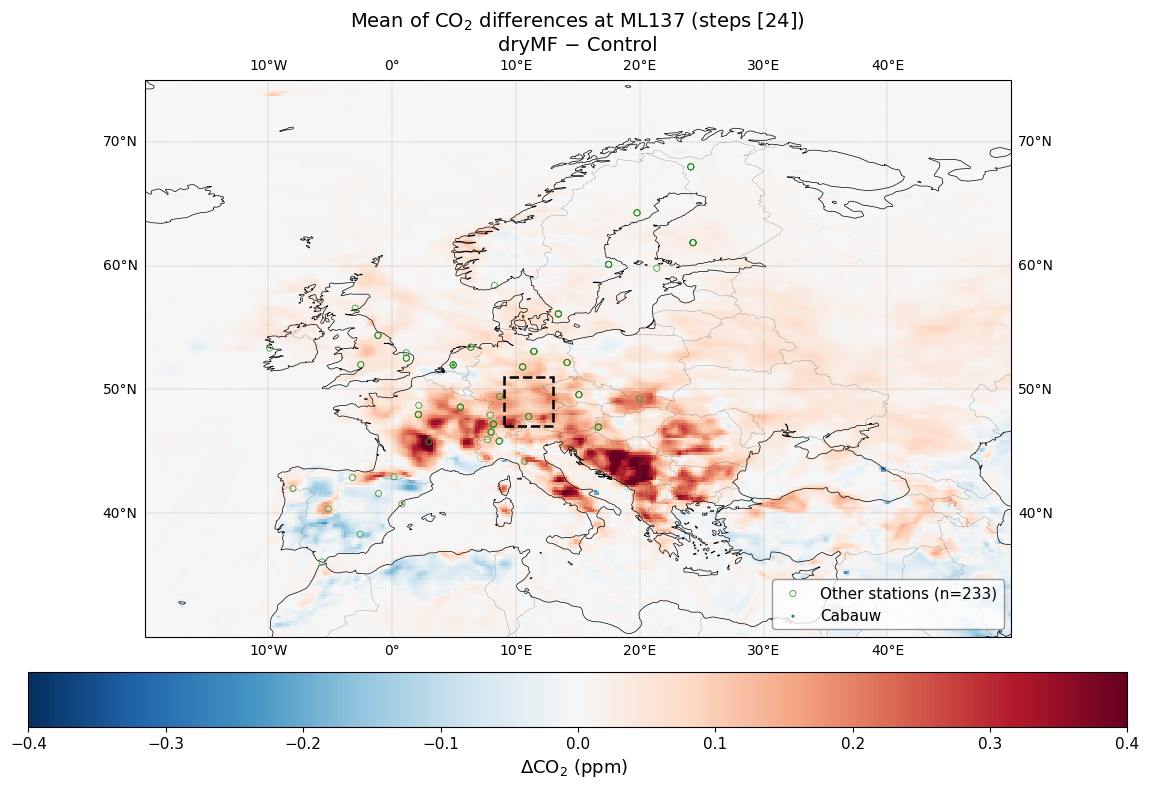

In [75]:

########################
##  Global Difference  ##
########################
import matplotlib.patches as mpatches

# runids[0] = control, runids[1] = experiment
runid_ctl, name_ctl, _ = runids[0]
runid_exp, name_exp, _ = runids[2]

# Steps to include in the mean (list of ints in hours, or None for all steps)
select_steps = [24,]  # e.g. [12, 24] or None

# Map extent: None = global  |  [lon_min, lon_max, lat_min, lat_max] = zoom in
# Examples:
# plot_extent = None                   # global
plot_extent = [-20, 50, 30, 75]      # Europe
#   plot_extent = [-130, -58, 15, 75]    # North America
#   plot_extent = [2, 8, 50, 54]         # Netherlands
#   plot_extent = [-82, -31, 7, -15]        # Amazon basin 

stat_extent = [9, 13, 47, 51]
# stat_extent = [360-70, 360-55,  -10,  5]
lon_min, lon_max, lat_min, lat_max = stat_extent

da_ctl = experiments_globe[runid_ctl]
da_exp = experiments_globe[runid_exp]

# Mean of differences (not difference of means)
diff_all = da_exp - da_ctl  # positive = experiment has more CO2
diff = select_and_mean(diff_all, steps=select_steps)

print(f'Regional mean: {diff.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max)).mean().values}')

lats = diff.latitude.values
lons = diff.longitude.values
diff_data = diff.values

# Build time-range label
steps_list = [int(s) for s in step.split("/")]
if select_steps is not None:
    steps_list = [s for s in steps_list if s in select_steps]
utc_start = datetime(int(inidate[:4]), int(inidate[4:6]), int(inidate[6:8]),
                     int(initime), tzinfo=timezone.utc) + timedelta(hours=steps_list[0])
utc_end   = datetime(int(enddate[:4]), int(enddate[4:6]), int(enddate[6:8]),
                     int(initime), tzinfo=timezone.utc) + timedelta(hours=steps_list[-1])
time_range_str = (f"{utc_start.strftime('%Y %b %d %H:%M')} – "
                  f"{utc_end.strftime('%Y %b %d %H:%M')} UTC")

# Symmetric colour scale
abs_max = np.nanpercentile(np.abs(diff_data), 99)
abs_max = max(abs_max, 0.1)  # avoid zero range
abs_max = 0.4

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

if plot_extent is None:
    ax.set_global()
else:
    ax.set_extent(plot_extent, crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(lons, lats, diff_data,
                     cmap='RdBu_r', vmin=-abs_max, vmax=abs_max,
                     transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', zorder=0)
ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f5', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5,        zorder=1)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':', zorder=1)
# Add horizontal reference lines at latitudes
# ax.axhline(0, color="k", lw=1, linestyle="-")      # equator solid line
# ax.axhline(30, color="k", lw=1, linestyle=":")    # +30° dashed line
# ax.axhline(-30, color="k", lw=1, linestyle=":")   # -30° dashed line

ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)

# Region bounding boxes (same definitions as in hourly_regional_bias.ipynb)
REGION_BOX_STYLE = dict(linewidth=1.8, edgecolor='black', facecolor='none', linestyle='--')
REGION_LABEL_KW  = dict(fontsize=9, fontweight='bold', color='black',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))


rect = mpatches.Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    transform=ccrs.PlateCarree(), zorder=2, **REGION_BOX_STYLE)
ax.add_patch(rect)

# Grey dots for all ICOS stations
sc_icos = ax.scatter(st_lons, st_lats, color='none', s=20, marker='o',
                     transform=ccrs.PlateCarree(), edgecolor='forestgreen', zorder=4, lw=0.5,
                     label=f'Other stations (n={len(st_lons)})')

# Named station markers on top
sc_cabauw = ax.scatter(cabauw['lon'], cabauw['lat'], color='forestgreen', s=5, marker='o',
                        transform=ccrs.PlateCarree(), edgecolor='none', zorder=5, label='Cabauw')

ax.legend(handles=[sc_icos, sc_cabauw], loc='lower right',
          fontsize=11, framealpha=0.8, edgecolor='gray')

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', shrink=0.7, pad=0.05)
cbar.set_label(f"$\\Delta$CO$_2$ (ppm)  ", fontsize=13)
cbar.ax.tick_params(labelsize=11)

step_label = f"steps {select_steps}" if select_steps else "all steps"
plt.title(f"Mean of CO$_2$ differences at ML{plot_level} ({step_label})\n{name_exp} − {name_ctl}", fontsize=14)
plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
# plt.savefig(f"{out_dir}/{runid_exp}vs{runid_ctl}_co2_ml{plot_level}_globe_{inidate}to{enddate}_mean_diff.png", dpi=150, bbox_inches='tight')
plt.show()


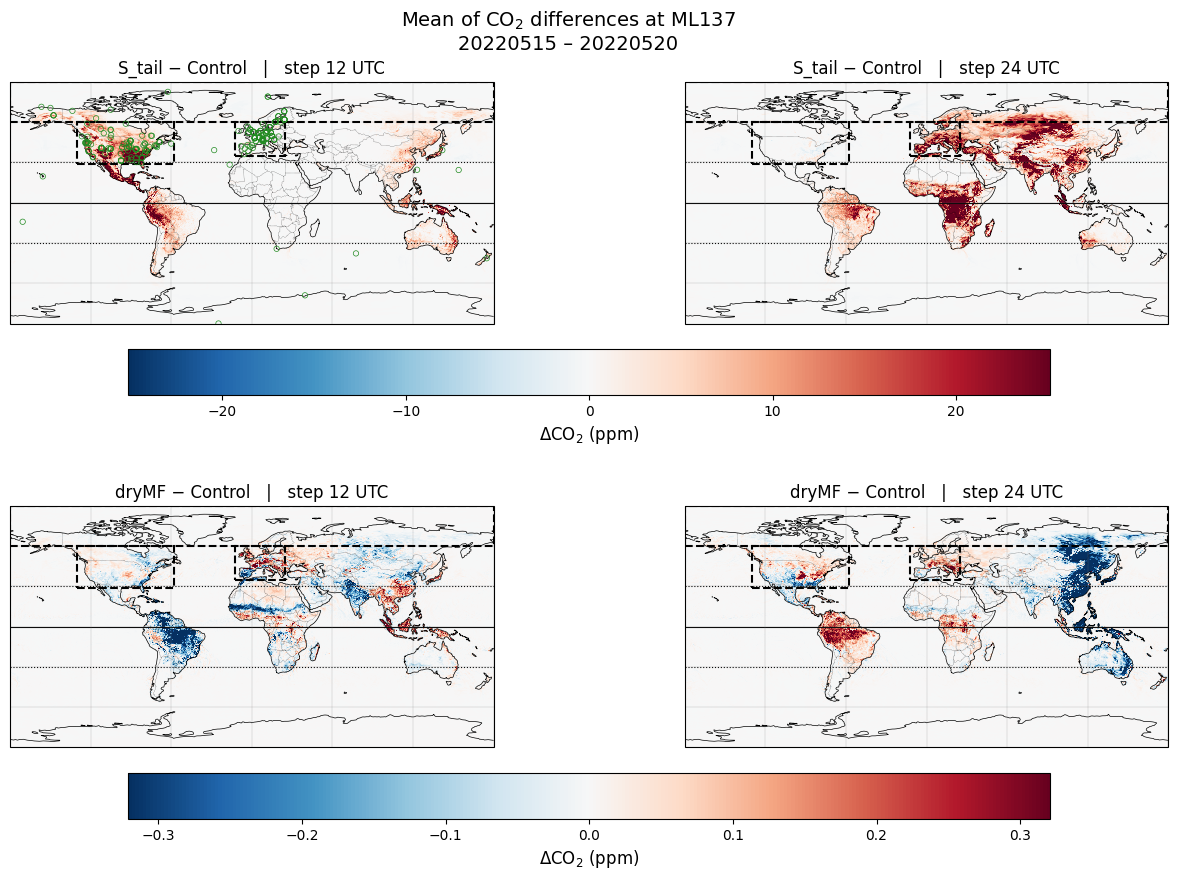

In [13]:
########################
##  2×2 Global Difference  ##
########################
runid_ctl, name_ctl, _ = runids[0]

panels_cfg = [
    (runids[1], 12),   # top-left
    (runids[1], 24),   # top-right
    (runids[2], 12),   # bottom-left
    (runids[2], 24),   # bottom-right
]

# Compute all panel data first
panel_data = []
for (runid_exp, name_exp, _), sel_step in panels_cfg:
    da_ctl = experiments_globe[runid_ctl]
    da_exp = experiments_globe[runid_exp]
    diff_all = da_exp - da_ctl
    diff = select_and_mean(diff_all, steps=[sel_step])
    panel_data.append((diff, name_exp, runid_exp, sel_step))

# Per-row symmetric colour scale: row 0 = panels 0,1  |  row 1 = panels 2,3
row_abs_max = [
    max(np.nanpercentile(np.abs(panel_data[0][0].values), 98.5),
        np.nanpercentile(np.abs(panel_data[1][0].values), 98.5), 0.1),
    max(np.nanpercentile(np.abs(panel_data[2][0].values), 98.5),
        np.nanpercentile(np.abs(panel_data[3][0].values), 98.5), 0.1),
]

fig, axes = plt.subplots(2, 2, figsize=(17, 9),
                          subplot_kw={'projection': ccrs.PlateCarree()},
                          gridspec_kw={'hspace': 0.35, 'wspace': 0.05})

meshes = {}  # store last mesh per row for colorbar
for idx, (ax, (diff, name_exp, runid_exp, sel_step)) in enumerate(zip(axes.flat, panel_data)):
    row = idx // 2
    lats = diff.latitude.values
    lons = diff.longitude.values

    m = ax.pcolormesh(lons, lats, diff.values,
                      cmap='RdBu_r', vmin=-row_abs_max[row], vmax=row_abs_max[row],
                      transform=ccrs.PlateCarree())
    meshes[row] = m

    ax.set_global()
    ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f5', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,        zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':', zorder=1)
    ax.axhline(0,   color='k', lw=0.8, linestyle='-')
    ax.axhline(30,  color='k', lw=0.8, linestyle=':')
    ax.axhline(-30, color='k', lw=0.8, linestyle=':')
    ax.gridlines(linewidth=0.3, color='gray', alpha=0.5)

    for rname, lat_min, lat_max, lon_min, lon_max in REGIONS:
        rect = mpatches.Rectangle(
            (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
            transform=ccrs.PlateCarree(), zorder=2,
            linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--')
        ax.add_patch(rect)

    ax.set_title(f"{name_exp} − {name_ctl}   |   step {sel_step:02d} UTC", fontsize=12)

axes[0,0].scatter(st_lons, st_lats, color='none', s=15, marker='o',
            transform=ccrs.PlateCarree(), edgecolor='forestgreen', zorder=4, lw=0.5)

# Adjust layout before adding colorbars so they land in the allocated space
fig.subplots_adjust(top=0.9, bottom=0.08, hspace=0.11)

# One colorbar per row, placed below its two panels
for row in range(2):
    cbar = fig.colorbar(meshes[row], ax=axes[row].tolist(),
                        orientation='horizontal', shrink=0.7, pad=0.08)
    cbar.set_label(r"$\Delta$CO$_2$ (ppm)", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

fig.suptitle(f"Mean of CO$_2$ differences at ML{plot_level}\n"
             f"{inidate} – {enddate}", fontsize=14)

os.makedirs(out_dir, exist_ok=True)
plt.savefig(f"{out_dir}/2x2_co2_ml{plot_level}_globe_{inidate}to{enddate}_mean_diff.png",
            dpi=150, bbox_inches='tight')
plt.show()
